In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
# Notebooks run from the notebooks folder, so the src folder is added to the path.
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, rasterio, matplotlib.pyplot as plt
from tqdm import tqdm
import config

Tile size: 10013 x 12760


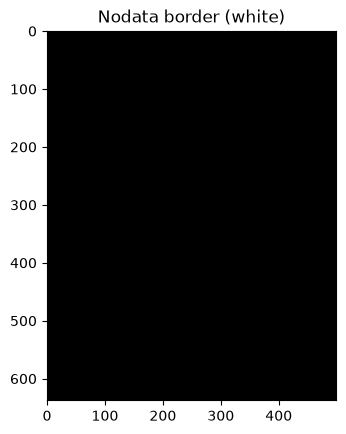

Study area 6.0 x 7.7 km | nodata fraction 0.0000


In [2]:
# Low resolution view of the full tile; white shows the nodata border.
with rasterio.open(config.NAIP_FILE) as photo:
    print("Tile size:", photo.width, "x", photo.height)
    overview = photo.read(1, out_shape=(photo.height // 20, photo.width // 20))
    area = photo.read(window=config.STUDY_AREA)
plt.imshow(overview == 0, cmap="gray"); plt.title("Nodata border (white)"); plt.show()
# Nodata pixels are those with a value of zero in all four bands.
nodata_fraction = (area.sum(axis=0) == 0).mean()
width_km, height_km = config.STUDY_AREA.width * 0.6 / 1000, config.STUDY_AREA.height * 0.6 / 1000
print(f"Study area {width_km:.1f} x {height_km:.1f} km | nodata fraction {nodata_fraction:.4f}")
if nodata_fraction > 0:
    print("WARNING: The study area includes nodata pixels. Adjust STUDY_AREA in config.py.")

In [3]:
import prepare
canopy_mask, landcover = prepare.align_labels()

Canopy fraction: 0.245


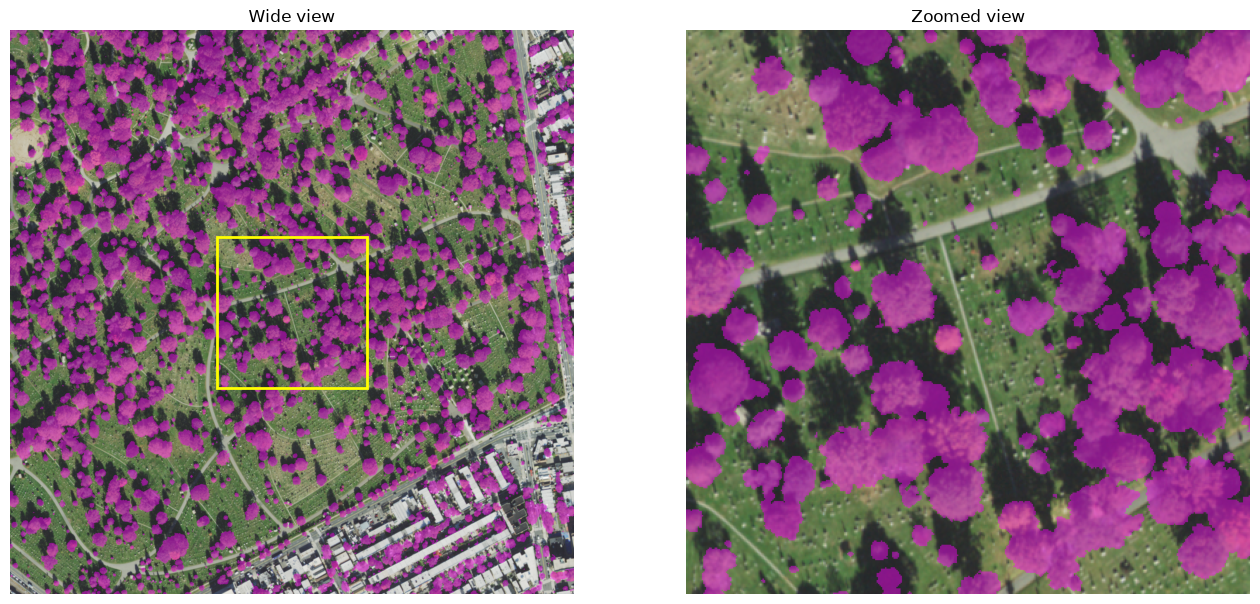

In [4]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from rasterio.windows import Window

WIDE, ZOOM = 1500, 400
height, width = canopy_mask.shape
# The zoom targets the 400 pixel window closest to 40% canopy, where edges reveal any shift.
_, zr, zc = min((abs(canopy_mask[r:r + ZOOM, c:c + ZOOM].mean() - 0.4), r, c)
                for r in range(0, height - ZOOM + 1, ZOOM) for c in range(0, width - ZOOM + 1, ZOOM))
# The wide view is centered on the zoomed area and kept inside the study area.
wr = int(np.clip(zr + ZOOM // 2 - WIDE // 2, 0, height - WIDE))
wc = int(np.clip(zc + ZOOM // 2 - WIDE // 2, 0, width - WIDE))
with rasterio.open(config.NAIP_FILE) as photo:
    rgb = photo.read([1, 2, 3], window=Window(config.STUDY_AREA.col_off + wc, config.STUDY_AREA.row_off + wr, WIDE, WIDE))

views = [(rgb, canopy_mask[wr:wr + WIDE, wc:wc + WIDE], "Wide view"),
         (rgb[:, zr - wr:zr - wr + ZOOM, zc - wc:zc - wc + ZOOM], canopy_mask[zr:zr + ZOOM, zc:zc + ZOOM], "Zoomed view")]
figure, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (image, mask, title) in zip(axes, views):
    # The axes are reordered for plotting, and non-canopy pixels are masked so only canopy is shaded.
    ax.imshow(np.transpose(image, (1, 2, 0)))
    ax.imshow(np.ma.masked_where(mask == 0, mask), cmap=ListedColormap(["#ff00ff"]), alpha=0.45)
    ax.set_title(title); ax.axis("off")
# Outline of the zoomed area; Rectangle takes (column, row).
axes[0].add_patch(Rectangle((zc - wc, zr - wr), ZOOM, ZOOM, fill=False, edgecolor="yellow", linewidth=2))
plt.savefig(config.FIGURES / "01_alignment_check.png", dpi=120, bbox_inches="tight"); plt.show()

In [5]:
prepare.cut_chips(landcover)

Tiles saved: 1911
